In [2]:
"""Class 1. Deep Feed Forward Network Layers and Architectures 


Objectives:
1. Different layers of deep feedforward network
2. How to create an DFN architecture using different ways
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [5]:
train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform)

In [6]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=64, 
    shuffle=True
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=64, 
    shuffle=False
)

In [12]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

print(len(images))
print(len(labels))
print(images[63].shape)
print(labels[63])

64
64
torch.Size([1, 28, 28])
tensor(5)


In [17]:
image = images[0].squeeze()
print(image.shape)
print(labels[0])

torch.Size([28, 28])
tensor(9)


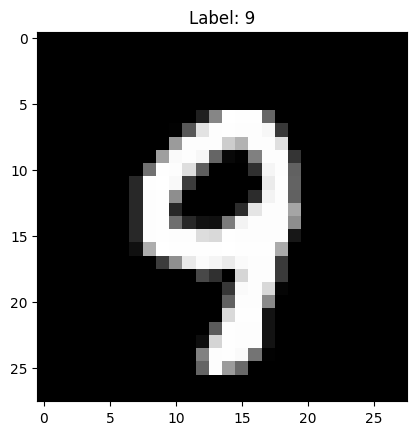

In [16]:
plt.imshow(image, cmap="gray")
plt.title(f"Label: {labels[0].item()}")
plt.show()

In [18]:
class DeepFFN(nn.Module):
    def __init__(self):
        super(DeepFFN, self).__init__()
        self.model = nn.Sequential(
            # Block 1
            nn.Flatten(), # converts multi dimensional array into vector
            nn.Linear(28 * 28, 256), # y = WX + b
            nn.BatchNorm1d(256), 
            nn.ReLU(), 
            nn.Dropout(0.3),
            
            # Block 2
            nn.Linear(256, 128),
            nn.ReLU(),
            
            # Block 3
            nn.Linear(128, 64),
            nn.ReLU(),
            
            nn.Linear(64, 10),
        )
    def forward(self, x):    
        return self.model(x)
    
model = DeepFFN().to(device)

In [24]:
(784+1)*256+(256+1)*128+(128+1)*64+(64+1)*10

242762

In [25]:
# parameters freezing: making the parameters untrainable i.e. no gradient descent will applicable to these parameters

total = sum(p.numel() for p in model.parameters())
trainable = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)
print(f"Total parameters: {total}")
print(f"Trainable parameters: {trainable}")

Total parameters: 242762
Trainable parameters: 242762


In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [20]:
def train(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [21]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [22]:
epochs = 5

for epoch in range(epochs):
    loss = train(model, train_loader)
    acc = evaluate(model, test_loader)

    print(f"Epoch {epoch+1}: Loss = {loss:.4f}, Test Accuracy = {acc:.2f}%")


Epoch 1: Loss = 0.4240, Test Accuracy = 94.24%
Epoch 2: Loss = 0.2155, Test Accuracy = 95.09%
Epoch 3: Loss = 0.1774, Test Accuracy = 96.40%
Epoch 4: Loss = 0.1540, Test Accuracy = 96.64%
Epoch 5: Loss = 0.1376, Test Accuracy = 96.95%


In [ ]:
""" 
When to use DFFN:
  examples are given in feature vector format i.e. x1, x2, x3, ..., x^n
  
  Core pipeline:
      Input > Linear > Activation > Dropout > Batch Normalization > ...> Output layer
"""